In [118]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [119]:
class Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = torch.nn.Sequential(
            torch.nn.Linear(1,32),
            torch.nn.Tanh(),
            torch.nn.Linear(32,32),
            torch.nn.Tanh(),
            torch.nn.Linear(32,32),
            torch.nn.Tanh(),
            torch.nn.Linear(32,1)
        )

    def forward(self,t):
        return self.layer(t)
model = Model()
model1 = Model()

In [120]:
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
optimizer1 = torch.optim.LBFGS(model1.parameters(), lr=1, max_iter=20, history_size=10)

In [121]:
def train1(epochs,omega):
    l = []
    t0 = torch.tensor([[0.0]],requires_grad=True)
    # t = torch.linspace(0, 4*torch.pi, 1000).view(-1, 1).requires_grad_(True)
    t = (torch.rand(1000)*(4*torch.pi)).view(-1, 1).requires_grad_(True)
    for i in range(epochs):
        def closure():
            optimizer1.zero_grad()
            x_0 = model1(t0)
            v_0 = torch.autograd.grad(x_0,t0,create_graph = True)[0]
            loss_ic = (x_0 - 0)**2 + (v_0 - 1)**2   # initial condition x(0) = 1 and v(0) = 0
            x = model1(t)
            v = torch.autograd.grad(x,t,grad_outputs=torch.ones_like(x),create_graph = True)[0]
            a = torch.autograd.grad(v,t,grad_outputs=torch.ones_like(v),create_graph = True)[0]
            loss_physics = torch.mean((a + omega**2 * x)**2)   # a + w**2 x = 0
            loss = 50* loss_physics + 500*loss_ic
            loss.backward()
            return loss
        current_loss = optimizer1.step(closure)
        l.append(current_loss.item())
        print(f"Epoch {i+1}/{epochs} Loss : {current_loss.item()}")
    return l

"""LBFGS is a multi-step optimizer. It re-evaluates the closure several times to calculate curvature. If the points change every time it checks,
the "landscape" is shifting under its feet. It’s like trying to map a mountain range while the mountains are moving."""

'LBFGS is a multi-step optimizer. It re-evaluates the closure several times to calculate curvature. If the points change every time it checks,\nthe "landscape" is shifting under its feet. It’s like trying to map a mountain range while the mountains are moving.'

In [122]:
def train(epochs,omega):
    l = []
    t0 = torch.tensor([[0.0]],requires_grad=True)
    t = torch.linspace(0, 4*torch.pi, 1000).view(-1, 1).requires_grad_(True)
    for i in range(epochs):
        optimizer.zero_grad()
        x_0 = model(t0)
        v_0 = torch.autograd.grad(x_0,t0,create_graph = True)[0]
        loss_ic = (x_0 - 0)**2 + (v_0 - 1)**2   # initial condition x(0) = 1 and v(0) = 0
        # t = torch.rand(1000,requires_grad=True)*(4*3.14)
        # t = t.view(-1,1)
        x = model(t)
        v = torch.autograd.grad(x,t,grad_outputs=torch.ones_like(x),create_graph = True)[0]
        a = torch.autograd.grad(v,t,grad_outputs=torch.ones_like(v),create_graph = True)[0]
        loss_physics = torch.mean((a + omega**2 * x)**2)   # a + w**2 x = 0
        loss = 10*loss_physics + 100*loss_ic
        l.append(loss.item())
        print(f"Epoch {i+1}/{epochs} Loss : {loss.item()}")
        loss.backward()
        optimizer.step()
        
    return l

Epoch 1/2000 Loss : 111.47881317138672
Epoch 2/2000 Loss : 104.4232406616211
Epoch 3/2000 Loss : 97.7429428100586
Epoch 4/2000 Loss : 91.39860534667969
Epoch 5/2000 Loss : 85.35662841796875
Epoch 6/2000 Loss : 79.57776641845703
Epoch 7/2000 Loss : 74.0213623046875
Epoch 8/2000 Loss : 68.65158081054688
Epoch 9/2000 Loss : 63.44068908691406
Epoch 10/2000 Loss : 58.370338439941406
Epoch 11/2000 Loss : 53.43201446533203
Epoch 12/2000 Loss : 48.62661361694336
Epoch 13/2000 Loss : 43.96373748779297
Epoch 14/2000 Loss : 39.46100616455078
Epoch 15/2000 Loss : 35.143226623535156
Epoch 16/2000 Loss : 31.04177474975586
Epoch 17/2000 Loss : 27.193635940551758
Epoch 18/2000 Loss : 23.64017105102539
Epoch 19/2000 Loss : 20.42535400390625
Epoch 20/2000 Loss : 17.59323501586914
Epoch 21/2000 Loss : 15.184537887573242
Epoch 22/2000 Loss : 13.232283592224121
Epoch 23/2000 Loss : 11.756460189819336
Epoch 24/2000 Loss : 10.757823944091797
Epoch 25/2000 Loss : 10.211913108825684
Epoch 26/2000 Loss : 10.064

Text(0, 0.5, 'Loss')

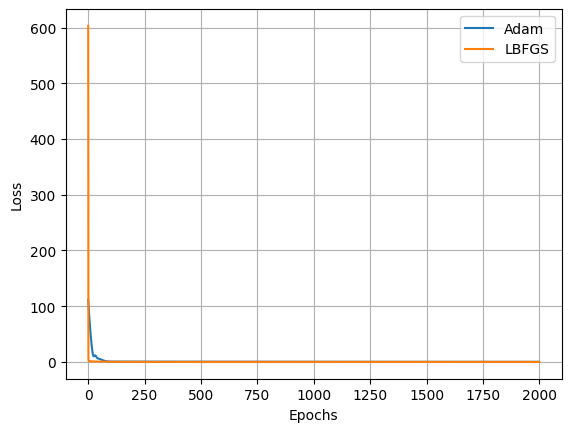

In [123]:
plt.plot(np.arange(0,2000),train(2000,1),label = 'Adam')
plt.plot(np.arange(0,2000),train1(2000,1),label = 'LBFGS')
plt.legend()
plt.grid()
plt.xlabel("Epochs")
plt.ylabel("Loss")

Text(0.5, 1.0, 'Harmonic Oscillator modelled using a PINN')

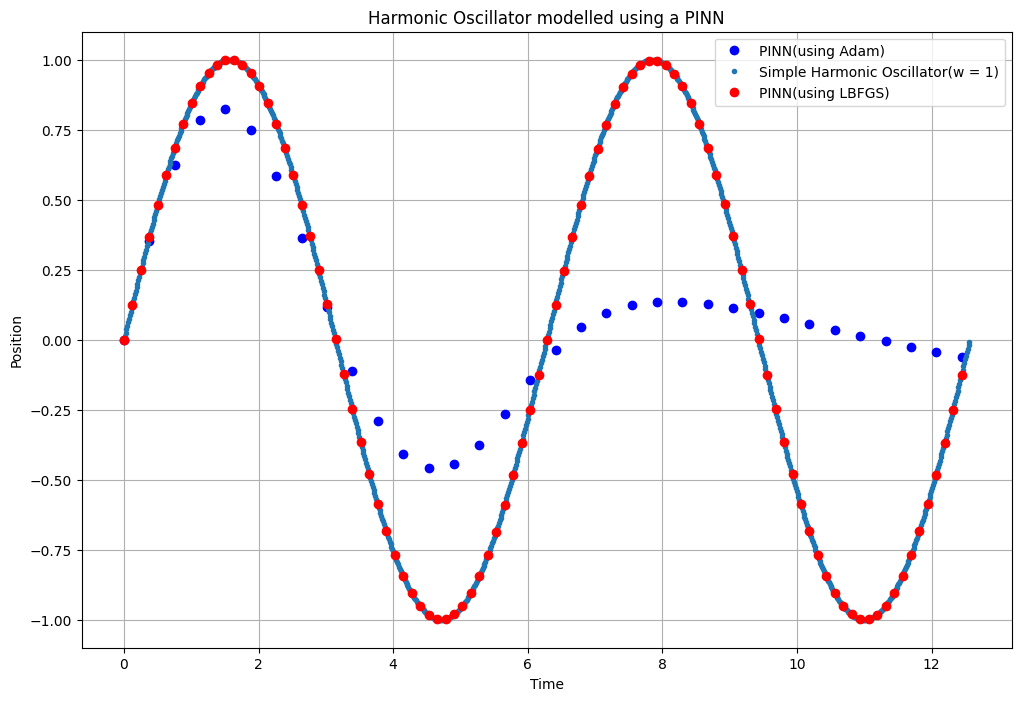

In [136]:
plt.figure(figsize=(12,8))
plt.plot(torch.linspace(0,4*3.14,1000)[::30],model(torch.linspace(0,4*3.14,1000).view(-1,1)).detach().numpy()[::30],'o',color='blue',label = 'PINN(using Adam)')
plt.plot(torch.linspace(0,4*3.14,1000),torch.sin(1.0*torch.linspace(0,4*3.14,1000)),'.',label="Simple Harmonic Oscillator(w = 1)")
plt.plot(torch.linspace(0,4*3.14,1000)[::10],model1(torch.linspace(0,4*3.14,1000).view(-1,1)).detach().numpy()[::10],'o',label = 'PINN(using LBFGS)',color='red')
plt.legend()
plt.grid()
plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Harmonic Oscillator modelled using a PINN")

In [111]:
damped_ho = Model()

def train_damped(epochs,gamma, omega,x_initial,v_initial):
    l = [0]
    t0 = torch.tensor([[0.0]],requires_grad=True)
    # t = torch.linspace(0, 2, 1000).view(-1, 1).requires_grad_(True)
    t = (torch.rand(1000)*(2)).view(-1, 1).requires_grad_(True)  #Converting to 2D as Linear layer expects 2D input 
    for i in range(epochs):
        def closure():
            optimizer1.zero_grad()
            x_0 = damped_ho(t0)
            v_0 = torch.autograd.grad(x_0,t0,create_graph = True)[0]
            loss_ic = (x_0 - x_initial)**2 + (v_0 - v_initial)**2   # initial condition x(0) = 1 and v(0) = 0
            x = damped_ho(t)
            v = torch.autograd.grad(x,t,grad_outputs=torch.ones_like(x),create_graph = True)[0]
            a = torch.autograd.grad(v,t,grad_outputs=torch.ones_like(v),create_graph = True)[0]
            loss_physics = torch.mean((a + 2*gamma*v + omega**2 * x)**2)   # a + 2*gamma*x + w**2*x = 0
            loss = 10*loss_physics + 500*loss_ic
            loss.backward()
            return loss
        current_loss = optimizer1.step(closure)
        if abs(current_loss - l[-1])<0.000001 and current_loss < 0.00001:
            l.append(current_loss.item())
            print(f"Epoch {i+1}/{epochs} Loss : {current_loss.item()}")
            break
        l.append(current_loss.item())
        print(f"Epoch {i+1}/{epochs} Loss : {current_loss.item()}")
    return l

optimizer1 = torch.optim.LBFGS(damped_ho.parameters(), lr=.1, max_iter=20, history_size=10)
# optimizer1 = torch.optim.Adam(damped_ho.parameters(), lr=0.001)
    

Epoch 1/2000 Loss : 1519.97705078125
Epoch 2/2000 Loss : 43.53459167480469
Epoch 3/2000 Loss : 20.038650512695312
Epoch 4/2000 Loss : 6.48153018951416
Epoch 5/2000 Loss : 5.012402534484863
Epoch 6/2000 Loss : 4.7397966384887695
Epoch 7/2000 Loss : 4.689303398132324
Epoch 8/2000 Loss : 4.688399791717529
Epoch 9/2000 Loss : 4.686903953552246
Epoch 10/2000 Loss : 4.66538667678833
Epoch 11/2000 Loss : 7.474395275115967
Epoch 12/2000 Loss : 4.657983779907227
Epoch 13/2000 Loss : 4.602010250091553
Epoch 14/2000 Loss : 4.591818332672119
Epoch 15/2000 Loss : 4.562249660491943
Epoch 16/2000 Loss : 4.561225414276123
Epoch 17/2000 Loss : 4.554337501525879
Epoch 18/2000 Loss : 4.555787086486816
Epoch 19/2000 Loss : 4.549597263336182
Epoch 20/2000 Loss : 4.549490451812744
Epoch 21/2000 Loss : 4.548915386199951
Epoch 22/2000 Loss : 4.545387268066406
Epoch 23/2000 Loss : 4.539964199066162
Epoch 24/2000 Loss : 4.537937164306641
Epoch 25/2000 Loss : 4.533930778503418
Epoch 26/2000 Loss : 4.527283668518

Text(0, 0.5, 'Loss')

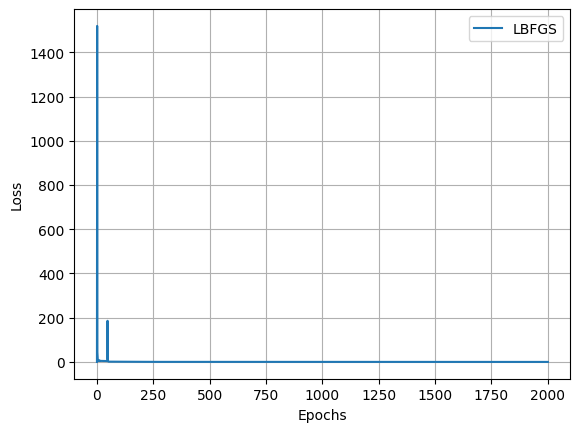

In [112]:
loss = train_damped(2000,2,10,0.1,0)
plt.plot(np.arange(0,len(loss)),loss,label = 'LBFGS')
plt.legend()
plt.grid()
plt.xlabel("Epochs")
plt.ylabel("Loss")     

Text(0.5, 1.0, 'Damped Harmonic Oscillator (gamma=2 and w_d = 9.8) modelled using PINN')

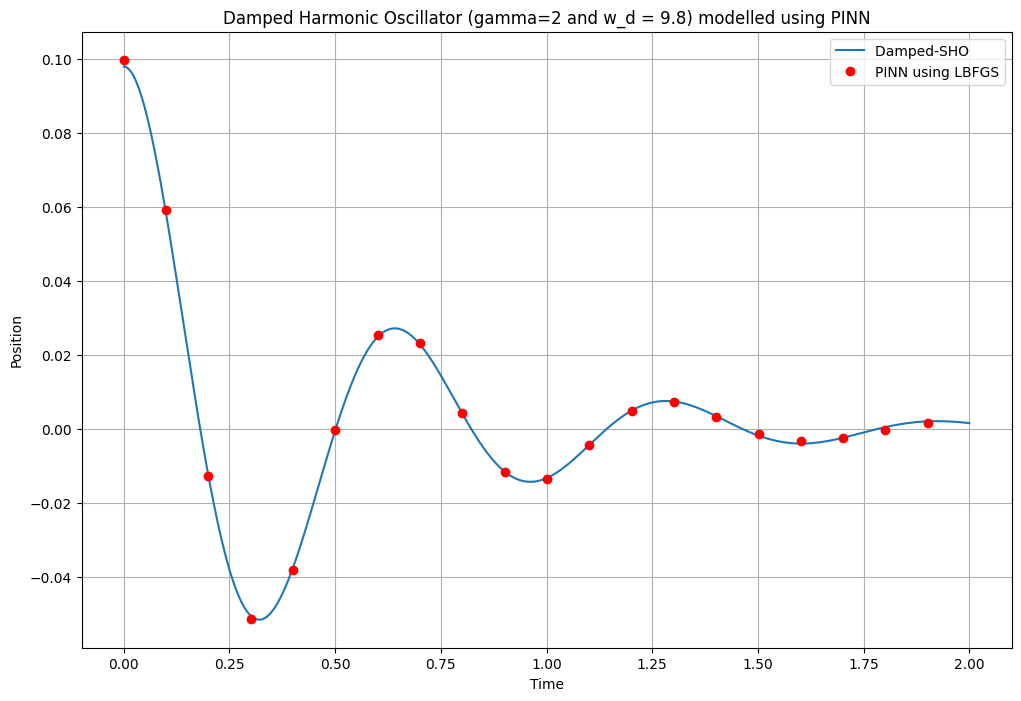

In [140]:
plt.figure(figsize=(12,8))
plt.plot(torch.linspace(0,2,1000),0.1*torch.exp(-2*torch.linspace(0,2,1000))*torch.cos(9.8*torch.linspace(0,2,1000)-0.2),'-',label="Damped-SHO ")
plt.plot(torch.linspace(0,2,1000)[::50],damped_ho(torch.linspace(0,2,1000).view(-1,1)).detach().numpy()[::50],'o',label = 'PINN using LBFGS',color='red')
plt.legend()
plt.grid()
plt.xlabel("Time")
plt.ylabel("Position")
plt.title('Damped Harmonic Oscillator (gamma=2 and w_d = 9.8) modelled using PINN')